In [1]:
# 진행과정
# 1. 데이터 파일 업로드하기
# 2. 데이터 불러오기
# 3. 불러온 데이터 분석하기
# 4. 데이터 합치기
# 5. 합쳐진 데이터로 시각화하기

In [2]:
# CCTV 데이터 /content/01. CCTV_in_Seoul.csv
# 인구 데이터 /content/01. population_in_Seoul.xls

In [3]:
# 처음 프롬프트 : CCTV 데이터와 인구데이터를 불러와줘
# 수정 프롬프트 : 인구 데이터를 불러올때 컬럼 행 3개인데, 3개의 컬럼 행을 참조해서
#                 "자치구","인구 합계 계", "인구 합계 여자", "65세 이상 고령자" 컬럼만 가져와서
#                 컬럼명을 쉽게 알아보게 수정해줘.
# CCTV 데이터에서 소계 기관명 컬럼만 남기고 다 삭제해줘


import pandas as pd

# CCTV 데이터 불러오기
CCTV_Seoul = pd.read_csv('/content/01. CCTV_in_Seoul.csv', usecols=['기관명', '소계'])

# 인구 데이터 불러오기 (엑셀 파일이므로 read_excel 사용)
# '자치구', '계', '여자', '계.1' 컬럼을 선택하고 이름을 변경합니다.
population_Seoul = pd.read_excel(
    '/content/01. population_in_Seoul.xls',
    header=2,
    usecols='B, D, F, G' # 자치구(B), 계(D), 여자(F), 계.1(G)를 선택합니다.
)
population_Seoul.rename(
    columns={
        '계': '인구 합계 계',
        '여자': '인구 합계 여자',
        '계.1': '65세 이상 고령자'
    },
    inplace=True
)

In [4]:
# 불러온 CCTV 데이터의 처음 5개 행을 보여줘

population_Seoul.head()

,자치구,인구 합계 계,인구 합계 여자,65세 이상 고령자
0,합계,10197604.0,5197599.0,9926968.0
1,종로구,162820.0,83145.0,153589.0
2,중구,133240.0,67450.0,124312.0
3,용산구,244203.0,125071.0,229456.0
4,성동구,311244.0,157476.0,303380.0


In [5]:
# "인구 합계 계" -> 전체인구 "인구 합계 여자" -> 전체여성 "65세 이상 고령자" -> 65세이상

population_Seoul.rename(
    columns={
        '인구 합계 계': '전체인구',
        '인구 합계 여자': '전체여성',
        '65세 이상 고령자': '65세이상'
    },
    inplace=True
)

In [6]:
# 인구 데이터도 5개행 보여줘
#
CCTV_Seoul.head()

,기관명,소계
0,강남구,2780
1,강동구,773
2,강북구,748
3,강서구,884
4,관악구,1496


In [7]:
# 구별로 인구 데이터와 CCTV데이터를 합쳐줘


# '합계' 행 제거
population_Seoul.drop(index=0, inplace=True)

# '자치구' 컬럼을 기준으로 정렬하여 혹시 모를 문제 방지
population_Seoul.sort_values(by='자치구', inplace=True)
CCTV_Seoul.sort_values(by='기관명', inplace=True)

# 두 데이터프레임 합치기
data_result = pd.merge(CCTV_Seoul, population_Seoul, left_on='기관명', right_on='자치구')

# 불필요한 '자치구' 컬럼 제거 (기관명과 중복되므로)
data_result.drop('자치구', axis=1, inplace=True)

# 합쳐진 데이터의 처음 5개 행 출력
display(data_result.head())

,기관명,소계,전체인구,전체여성,65세이상
0,강남구,2780,570500.0,297199.0,565550.0
1,강동구,773,453233.0,227806.0,449019.0
2,강북구,748,330192.0,168506.0,326686.0
3,강서구,884,603772.0,309339.0,597248.0
4,관악구,1496,525515.0,260752.0,507203.0


In [9]:
data_result.rename(columns={'소계': 'CCTV대수'}, inplace=True)
display(data_result.head())

,기관명,CCTV대수,전체인구,전체여성,65세이상
0,강남구,2780,570500.0,297199.0,565550.0
1,강동구,773,453233.0,227806.0,449019.0
2,강북구,748,330192.0,168506.0,326686.0
3,강서구,884,603772.0,309339.0,597248.0
4,관악구,1496,525515.0,260752.0,507203.0


In [10]:
# 소계 컬럼명은 CCTV대수로 변경해줘
# CCTV 대수가 많은 기관명의 순으로 정렬해줘

# 'CCTV대수' 컬럼을 기준으로 내림차순 정렬
data_result.sort_values(by='CCTV대수', ascending=False, inplace=True)

# 정렬된 데이터의 처음 5개 행 출력
display(data_result.head())

,기관명,CCTV대수,전체인구,전체여성,65세이상
0,강남구,2780,570500.0,297199.0,565550.0
18,양천구,2034,479978.0,242861.0,475949.0
14,서초구,1930,450310.0,234046.0,445994.0
21,은평구,1873,494388.0,254168.0,489943.0
20,용산구,1624,244203.0,125071.0,229456.0


In [ ]:
# CCTV가 많은 기관명 순으로 bar chart를 그려줘

# 나눔 폰트 설치
!sudo apt-get install -y fonts-nanum-extra
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

# 설치 후 런타임 재시작이 필요할 수 있습니다.
# '런타임' -> '런타임 다시 시작'을 클릭하거나 Ctrl+M . 을 누르세요.
# 런타임 재시작 후에는 이 셀과 그래프를 그리는 셀을 다시 실행해야 합니다.

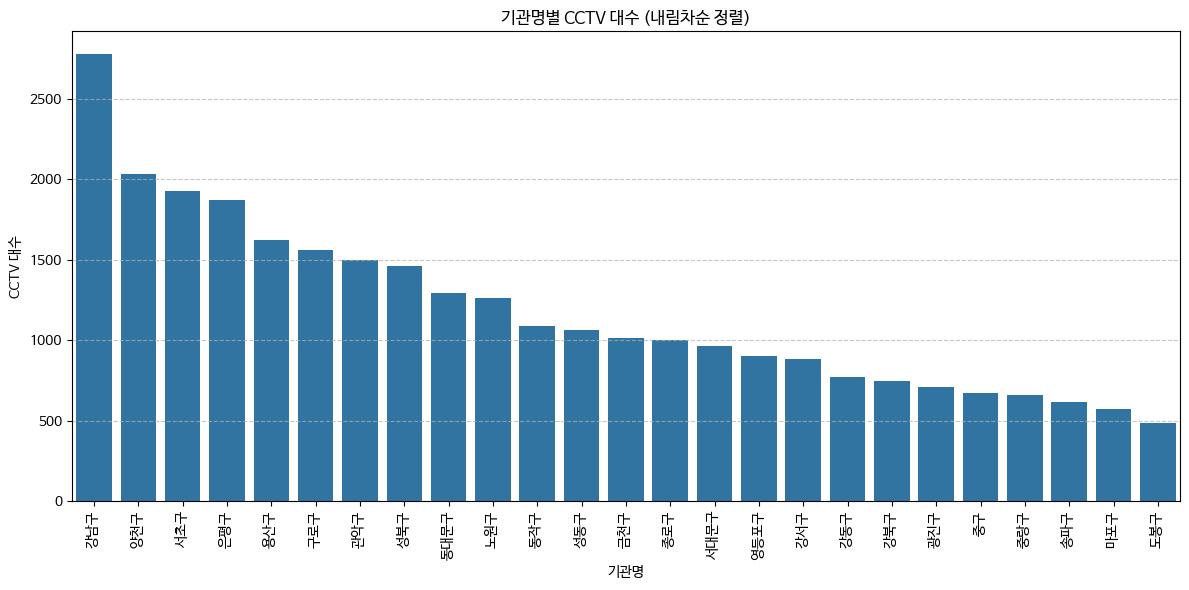

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정 (Colab 환경에 따라 필요)
plt.rc('font', family='NanumBarunGothic') # Colab에 나눔고딕 폰트 설치 후 사용
plt.rcParams['axes.unicode_minus'] = False # 한글 폰트 사용 시 마이너스 부호 깨짐 방지

plt.figure(figsize=(12, 6))
sns.barplot(x='기관명', y='CCTV대수', data=data_result)
plt.title('기관명별 CCTV 대수 (내림차순 정렬)')
plt.xlabel('기관명')
plt.ylabel('CCTV 대수')
plt.xticks(rotation=90) # 기관명 라벨이 겹치지 않도록 회전
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # 그래프 요소들이 잘 보이도록 레이아웃 조정
plt.show()

In [11]:
data_result.rename(columns={'소계': 'CCTV대수'}, inplace=True)
display(data_result.head())

,기관명,CCTV대수,전체인구,전체여성,65세이상
0,강남구,2780,570500.0,297199.0,565550.0
18,양천구,2034,479978.0,242861.0,475949.0
14,서초구,1930,450310.0,234046.0,445994.0
21,은평구,1873,494388.0,254168.0,489943.0
20,용산구,1624,244203.0,125071.0,229456.0
